In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df =pd.read_csv('C:/Users/Lenovo/Downloads/Iris - all-numbers.csv')

In [6]:
df.head()

,5.1,3.5,1.4,0.2,0
0,4.9,3.0,1.4,0.2,0
1,4.7,3.2,1.3,0.2,0
2,4.6,3.1,1.5,0.2,0
3,5.0,3.6,1.4,0.2,0
4,5.4,3.9,1.7,0.4,0


Columns Names are:
5.1: Sepal length
3.5: Sepal width
1.4: Petal length
0.2: Petal width
0: 3 classes 0(Iris Setosa) 1(Iris versicolor) 2(Iris virginica)

In [3]:
#Scaling
X= df.drop('0',axis=1)

scalar=StandardScaler()

X_scaled =scalar.fit_transform(X)



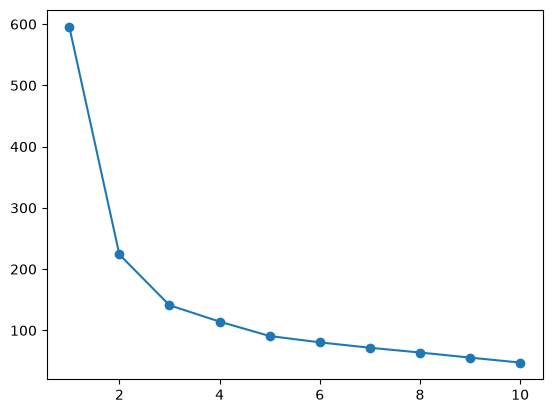

In [4]:
# finding the best k
from sklearn.cluster import KMeans
inertias = []

for k in range(1, 11):
 km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
 inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o") # look for the elbow

In [5]:
#silhouette score for 2 clusters

from sklearn.metrics import silhouette_score


km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
print(km.cluster_centers_) 

score = silhouette_score(X_scaled, labels)
score

[[-1.02231952  0.84556604 -1.31672615 -1.26588811]
 [ 0.50093656 -0.41432736  0.64519582  0.62028517]]


0.5787647071267112

In [8]:
#silhouette score for 3 clusters

km2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels2 = km2.fit_predict(X_scaled)
print(km2.cluster_centers_) 

score = silhouette_score(X_scaled, labels2)
score

[[-1.02231952  0.84556604 -1.31672615 -1.26588811]
 [ 1.12923094  0.10355011  0.98996731  1.01085787]
 [-0.05623015 -0.87357719  0.33945506  0.27392825]]


0.45655541185952575

2 clusters is better with 0.57 silhouette score 

In [10]:
# making 2D df to plot
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              # (150, 4) → (150, 2)
centers_2d = pca.transform(km.cluster_centers_)

Text(0.5, 1.0, 'Kmeans Clusters')

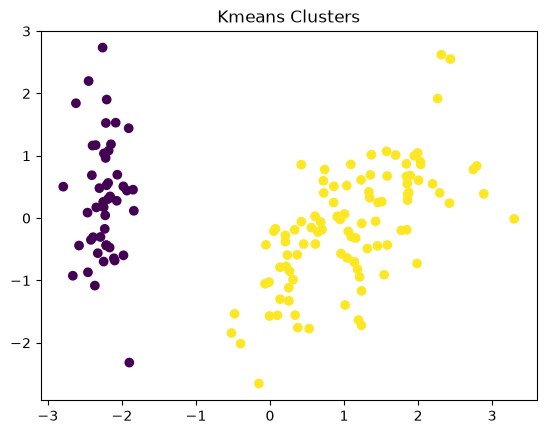

In [11]:
#The plot
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('Kmeans Clusters')

In [62]:
df['cluster'] = labels
print(df.groupby('cluster').mean())

              5.1       3.5       1.4       0.2    0
cluster                                             
0        5.004082  3.416327  1.465306  0.244898  0.0
1        6.262000  2.872000  4.906000  1.676000  1.5


there are 2 clusters

 cluster 0 has a sepal with length 5 and width 3 with petal length 1.4 and width 0.2 (mean), real life example :Iris Setosa
 cluster  1 has a sepal with length 6 and width 2.8 with petal length 4.9 and width 1.6 (mean), real life example :Virginia Iris

